# RBFE calculations of a Protein-Membrane System

This tutorial walks you through the process of setting up a relative binding free energy (RBFE) simulation campaign for a membrane protein system using OpenFE.

Unlike RBFE calculations for soluble proteins, where solvation is handled automatically in the protocol, membrane protein systems must be provided as fully solvated and pre-equilibrated, including box vectors. You can use tools such as `packmol-memgen`, `CHARMM-GUI`, or `Maestro` to prepare these systems.

Note: This tutorial currently places some emphasis on importing inputs from `Maestro`.

In [1]:
import numpy as np
import openmm
import openfe
from openfe import ProteinMembraneComponent, ProteinComponent
from openff.units import unit
from rdkit import Chem

/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'validate_default' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'validate_default' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/openmoltools/utils.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filenam

## (Optional) Combining System Components into a Single PDB File

Maestro exports solvated protein-membrane systems in a non-standard PDB format that OpenMM cannot directly read. To simplify the workflow, it is often easier to save different parts of the system separately—such as the protein, lipids, and water—and then combine them into a single PDB file.

It is essential that the lipid molecules include bond information in the CONECT records of the PDB file to ensure proper topology recognition by OpenMM.

Using OpenMM’s Modeller, the components can be merged as follows:

In [2]:
# Specifying input and output filenames
pdb_lipids = 'a2a/a2a_lipids.pdb'
pdb_protein = 'a2a/a2a_protein.pdb'
pdb_water = 'a2a/a2a_water.pdb'
pdb_complex = 'a2a/a2a_complex.pdb' # specify the output filename

#### Step 1: Load each component

We start by loading the protein, lipids, and water as `ProteinComponent` objects from their respective PDB files:

In [3]:
protein = ProteinComponent.from_pdb_file(pdb_protein)
lipids = ProteinComponent.from_pdb_file(pdb_lipids)
water = ProteinMembraneComponent.from_pdb_file(pdb_water)

/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/gufe/vendor/pdb_file/pdbstructure.py:465: UserWarning: WARNING: two consecutive residues with same number (ATOM   3205  N   GLU A 219       9.932   6.197 -38.597  1.00  0.00           N  , ATOM   3220 HH33 ACE A 219      11.901   4.558 -37.817  0.00  0.00           H  )
  warnings.warn(


#### Step 2: Merge components using OpenMM’s Modeller and save the merged system to a single PDB file

We create a Modeller with the protein first, then add lipids and water. This ensures all atoms are included in a single system. Finally, we write the combined system to a new PDB file that is ready for simulation.

In [4]:
# Create modeller using the protein inputs
modeller = openmm.app.Modeller(protein.to_openmm_topology(), protein.to_openmm_positions())
# Add the lipids
modeller.add(lipids.to_openmm_topology(), lipids.to_openmm_positions())
# Add the solvent
modeller.add(water.to_openmm_topology(), water.to_openmm_positions())
# Write out the new topology and positions
mergedTopology = modeller.topology
mergedPositions = modeller.positions
with open(pdb_complex, "w") as f:
    openmm.app.pdbfile.PDBFile.writeFile(modeller.topology, modeller.positions, f)

## Add Periodic Box Vectors

The ProteinMembraneComponent requires periodic box vectors to define the simulation box. There are several ways to provide these vectors:

1. **`CRYST` record in the PDB file**  
   If your PDB file includes a CRYST record (common in files exported from Maestro or other modeling tools), OpenMM can automatically read the box vectors from it.

2. **Manually specifying box vectors**  
   You can provide the box vectors explicitly in OpenMM format (see below).

3. **Inferring from atomic positions**  
   Box vectors can be estimated from the atomic coordinates in the PDB file.
   Caveat: This approach can be inaccurate if the PDB comes from a previous simulation and some atoms are positioned in periodic images. 

> **Maestro-specific note:**  
> - When merging multiple components exported from Maestro, `CRYST` records are not currently preserved in the combined output PDB file. If one of the original input files contains valid `CRYST` information (for example, `a2a_water.pdb` in this case), you can load that file directly as a `ProteinMembraneComponent` and extract the box vectors from it, as shown below.

#### Option 1: `CRYST` record in the PDB file

Box vectors are automatically recognized when stored in the `CRYST` record. In our case, only the `a2a_water.pdb` file had a `CRYST` record. 

In [5]:
a2a_cryst = "a2a/a2a_water.pdb"

In [6]:
component_with_box = openfe.ProteinMembraneComponent.from_pdb_file(a2a_cryst)

In [7]:
box_vector = component_with_box.box_vectors
box_vector

Magnitude,[[6.9587 0.0 0.0] [0.0 5.9164 0.0] [0.0 0.0 9.2692]]
Units,nanometer


#### Option 2: Manually provide box vectors

Some membrane setup tools (e.g. CHARMM-GUI or Maestro) store the periodic box vectors in the outputs of the membrane-building step or a prior equilibration simulation. In these cases, you can manually supply the box vectors to OpenFE.

Box vectors must be provided as a NumPy array with OpenFF units and specified in their reduced form, as required by OpenMM.

For details on reduced box vectors and periodic boundary conditions, see the OpenMM documentation:
https://docs.openmm.org/latest/userguide/theory/05_other_features.html#periodic-boundary-conditions

In [8]:
box_vector = np.array([
    [6.9587, 0.0, 0.0],
    [0.0, 5.9164, 0.0],
    [0.0, 0.0, 9.2692]
]) * unit.nanometer

In [9]:
membrane_protein_user_box = openfe.ProteinMembraneComponent.from_pdb_file(pdb_complex, box_vectors=box_vector)

In [10]:
membrane_protein_user_box.box_vectors

Magnitude,[[6.9587 0.0 0.0] [0.0 5.9164 0.0] [0.0 0.0 9.2692]]
Units,nanometer


#### Option 3: Infer box vectors from atomic positions

As a fallback, box vectors can be estimated from the atomic coordinates in the PDB file. An orthorhombic box is constructed by taking the minimum and maximum coordinates along each axis and expanding the resulting bounding box by an optional padding.

> **Caveat:**  
> - The system must be fully wrapped into a single periodic image.  If atoms are split across periodic boundaries, the inferred box will be incorrect.


This approach is convenient when no box information is available, but should generally be used as a last resort.

In [11]:
membrane_protein_infer_box = openfe.ProteinMembraneComponent.from_pdb_file(pdb_complex, infer_box_vectors=True)

/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/gufe/components/solvatedpdbcomponent.py:282: UserWarning: Box vectors were inferred from the atomic coordinates.
Note: This heuristic assumes that the coordinates reflect the true periodic unit cell. It may produce incorrect box dimensions for structures that were post-processed (e.g., unwrapped after MD).
Inferred box vectors: [[9.445200000000002 0.0 0.0] [0.0 8.196100000000001 0.0] [0.0 0.0 9.8092]] nanometer
Applied padding: 0.2 nanometer
  warnings.warn(


This box is much bigger than the other boxes since PBC is not explicitly handled in `infer_box_vector`.

In [12]:
membrane_protein_infer_box.box_vectors

Magnitude,[[9.445200000000002 0.0 0.0] [0.0 8.196100000000001 0.0] [0.0 0.0 9.8092]]
Units,nanometer


In [13]:
# The density is quite low for this case since the box is too big
membrane_protein_infer_box.density

<Quantity(519.107133, 'gram / liter')>

### Validating Your `ProteinMembraneComponent`

After adding periodic box vectors, it’s a good practice to validate your `ProteinMembraneComponent`. This helps catch common issues early, specifically:

- **Number of waters:**  
  Ensures that the system contains at least the specified `min_waters`. If there are too few, it may indicate missing solvent.  
  **Default:** 50

- **System density:**  
  Checks that the density is above `min_density`. A very low density often signals incorrect box vectors or missing solvent.  
  **Default:** 500 g/L

If any of these checks fail, the `validate` method will raise a `ValueError`, indicating that the system may be missing solvent or have incorrect box vectors.

In [15]:
# Our created `ProteinMembraneComponent` should not give any errors
membrane_protein_user_box.validate()

In [16]:
# The pure protein, without lipids and waters, should give errors
only_protein = openfe.ProteinMembraneComponent.from_pdb_file(pdb_protein, box_vectors=box_vector)
only_protein.validate()

/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/gufe/vendor/pdb_file/pdbstructure.py:465: UserWarning: WARNING: two consecutive residues with same number (ATOM   3205  N   GLU A 219       9.932   6.197 -38.597  1.00  0.00           N  , ATOM   3220 HH33 ACE A 219      11.901   4.558 -37.817  0.00  0.00           H  )
  warnings.warn(


ValueError: SolvatedPDBComponent validation failed:
- Only 0 water molecules detected (expected ≥ 50).
- Estimated system density is very low.
  Density: 141.802 gram / liter
This usually indicates missing solvent or incorrect box vectors.

# Loading the ligands and creating a `LigandNetwork`

Next, we load the small molecules for which we want to calculate free energies. In this example, the ligands are stored in an SDF file containing multiple molecules. We can load them using RDKit’s SDMolSupplier and pass them to OpenFE:

In [17]:
ligands_sdf = Chem.SDMolSupplier("a2a/ligands_am1bcc.sdf", removeHs=False)

# Now pass these to form a list of Molecules
ligands = [openfe.SmallMoleculeComponent(sdf) for sdf in ligands_sdf]

The `LigandNetwork` is then created using three main components:

- **Atom Mapper** – Proposes potential atom mappings between ligand pairs.  
- **Scorer** – Evaluates the quality of each proposed mapping.  
- **Network Planner** – Generates the network itself.

In [18]:
mapper = openfe.setup.KartografAtomMapper()
scorer = openfe.lomap_scorers.default_lomap_score
network_planner = openfe.ligand_network_planning.generate_lomap_network

In [19]:
ligand_network = network_planner(
    ligands=ligands,
    mappers=[mapper],
    scorer=scorer
)

INFO:root:Trying to remove edge 2-4 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 2-4
INFO:root:Trying to remove edge 3-5 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 3-5
INFO:root:Trying to remove edge 3-7 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 3-7
INFO:root:Trying to remove edge 3-14 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 3-14
INFO:root:Trying to remove edge 4-15 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 4-15
INFO:root:Trying to remove edge 5-12 with similarity 0.606531
INFO:root:Checking edge deletion on distance-to-actives 0 vs 0
INFO:root:Removed edge 5-12
INFO:root:Trying to remove edge 9-16 with similarity 0.606531
INFO:root:Checking edge de

In [20]:
# get the first edge; it automatically displays in a Jupyter notebook
mapping = next(iter(ligand_network.edges))

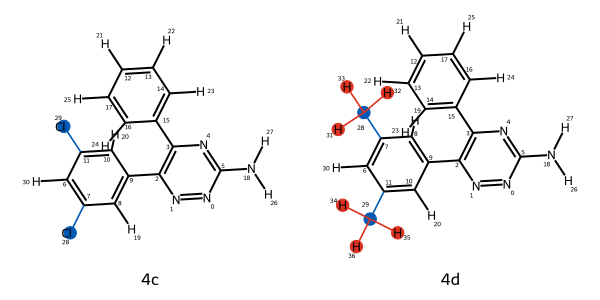

In [21]:
mapping

## Creating the AlchemicalNetwork

The **`AlchemicalNetwork`** contains all the information needed to run a complete RBFE campaign. Each `Transformation` represents one alchemical mutation between a pair of ligands in a specific environment (either **solvent** or **protein-membrane complex**).

In this example, we loop over all ligand mappings, and for each mapping, we loop over the legs (`solvent` and `complex`) to create the corresponding `Transformation` objects.

A key feature is the use of **`_adaptive_settings`** in `RelativeHybridTopologyProtocol`, which automatically configures the protocol based on the system composition:

- **Complex leg (protein-membrane)**  
  - Uses a `MonteCarloMembraneBarostat` for proper membrane pressure coupling.  
  - Adds the relevant lipid forcefield (by default, **AMBER lipid17**). Additional lipid forcefields from OpenMMForcefields—such as AMBER lipid21 or CHARMM36—can also be added (note: not yet tested with this Protocol).

- **Solvent leg**  
  - Uses a standard `MonteCarloBarostat` for bulk solvent pressure regulation.

In [23]:
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
transformations = []
for mapping in ligand_network.edges:
    for leg in ['solvent', 'complex']:
        if leg == 'solvent':
            sysA_dict = {'ligand': mapping.componentA,
                         'solvent': openfe.SolventComponent()}
            sysB_dict = {'ligand': mapping.componentB,
                         'solvent': openfe.SolventComponent()}

        if leg == 'complex':
            sysA_dict = {'ligand': mapping.componentA,
                         'protein': membrane_protein_user_box}
            sysB_dict = {'ligand': mapping.componentB,
                         'protein': membrane_protein_user_box}

        # we don't have to name objects, but it can make things (like filenames) more convenient
        system_a = openfe.ChemicalSystem(sysA_dict, name=f"{mapping.componentA.name}_{leg}")
        system_b = openfe.ChemicalSystem(sysB_dict, name=f"{mapping.componentB.name}_{leg}")

        prefix = "rbfe_"  # prefix is only to exactly reproduce CLI
        protocol_settings = RelativeHybridTopologyProtocol.default_settings()
        protocol_settings.protocol_repeats = 1

        protocol = RelativeHybridTopologyProtocol(
            settings=RelativeHybridTopologyProtocol._adaptive_settings(
                stateA=system_a,
                stateB=system_b,
                mapping=mapping,
                initial_settings=protocol_settings,
            ),
        )
            

        transformation = openfe.Transformation(
            stateA=system_a,
            stateB=system_b,
            mapping=mapping,
            protocol=protocol,  # use protocol created above
            name=f"{prefix}{system_a.name}_{system_b.name}"
        )
        transformations.append(transformation)

network = openfe.AlchemicalNetwork(transformations)

/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/openfe/protocols/openmm_rfe/hybridtop_protocols.py:177: PydanticDeprecatedSince20: The `copy` method is deprecated; use `model_copy` instead. See the docstring of `BaseModel.copy` for details about how to handle `include` and `exclude`. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  protocol_settings = initial_settings.copy(deep=True)
/Users/hannahbaumann/miniforge3/envs/membrane/lib/python3.13/site-packages/openfe/protocols/openmm_rfe/hybridtop_protocols.py:177: PydanticDeprecatedSince20: The `copy` method is deprecated; use `model_copy` instead. See the docstring of `BaseModel.copy` for details about how to handle `include` and `exclude`. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  protocol_settings = initial_settings.copy(deep=True)
/Users

In [24]:
# A solvent leg transformation uses the `MonteCarloBarostat`
transformations[-2].protocol.settings.integrator_settings

{'barostat': 'MonteCarloBarostat',
 'barostat_frequency': <Quantity(25.0, 'timestep')>,
 'constraint_tolerance': 1e-06,
 'langevin_collision_rate': <Quantity(1.0, '1 / picosecond')>,
 'n_restart_attempts': 20,
 'reassign_velocities': False,
 'remove_com': False,
 'surface_tension': <Quantity(0, 'bar * nanometer')>,
 'timestep': <Quantity(4.0, 'femtosecond')>}


In [25]:
# A complex leg transformation uses the `MonteCarloMembraneBarostat`
transformations[-1].protocol.settings.integrator_settings

{'barostat': 'MonteCarloMembraneBarostat',
 'barostat_frequency': <Quantity(25.0, 'timestep')>,
 'constraint_tolerance': 1e-06,
 'langevin_collision_rate': <Quantity(1.0, '1 / picosecond')>,
 'n_restart_attempts': 20,
 'reassign_velocities': False,
 'remove_com': False,
 'surface_tension': <Quantity(0, 'bar * nanometer')>,
 'timestep': <Quantity(4.0, 'femtosecond')>}


## Writing the `Transformation`s to disk

We'll write out each transformation to disk, so that they can be run independently using the openfe quickrun command:

In [26]:
import pathlib
# first we create the directory
transformation_dir = pathlib.Path("transformations")
transformation_dir.mkdir(exist_ok=True)

# then we write out each transformation
for transformation in network.edges:
    transformation.to_json(transformation_dir / f"{transformation.name}.json")